In [1]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

In [2]:
# Match fraction for 1 < z < 1.5 for hsc and des for some little area of the sky
# Big enough area, 10 arcmins2, largest one you can get tbh 

# take a large + clean area of hsc, take a large + clean area of des
# calculate within that region, number of galaxies in the matched sample relative to the parent DESI sample

# Take large + clean areas of the surveys

load the matched catalog, find the RA and DEC cuts youd want to do 

load the full catalog, but only within the proper RA and Dec regions 

calcualte the match fraction from the loaded full catalog with appropriate RA and Dec region 

In [46]:
import math

def calculate_sky_area(ra1, ra2, dec1, dec2):
    """
    Inputs should be in degrees.
    """
    ra_span = ra2 - ra1
    
    # Convert dec from degrees to radians
    dec1_rad = math.radians(dec1)
    dec2_rad = math.radians(dec2)
    
    # spherical area of a sky patch
    # A = (RA_span) * (180 / pi) * (sin(Dec2) - sin(Dec1))
    area = ra_span * (180 / math.pi) * (math.sin(dec2_rad) - math.sin(dec1_rad))
    
    return area

## HSC

In [4]:
hscy3 = '/scratch/gpfs/dy9683/matched_catalogs/hscy3_matched_lensing_match_1.csv'
hsc_catalog_matched = pd.read_csv(hscy3)

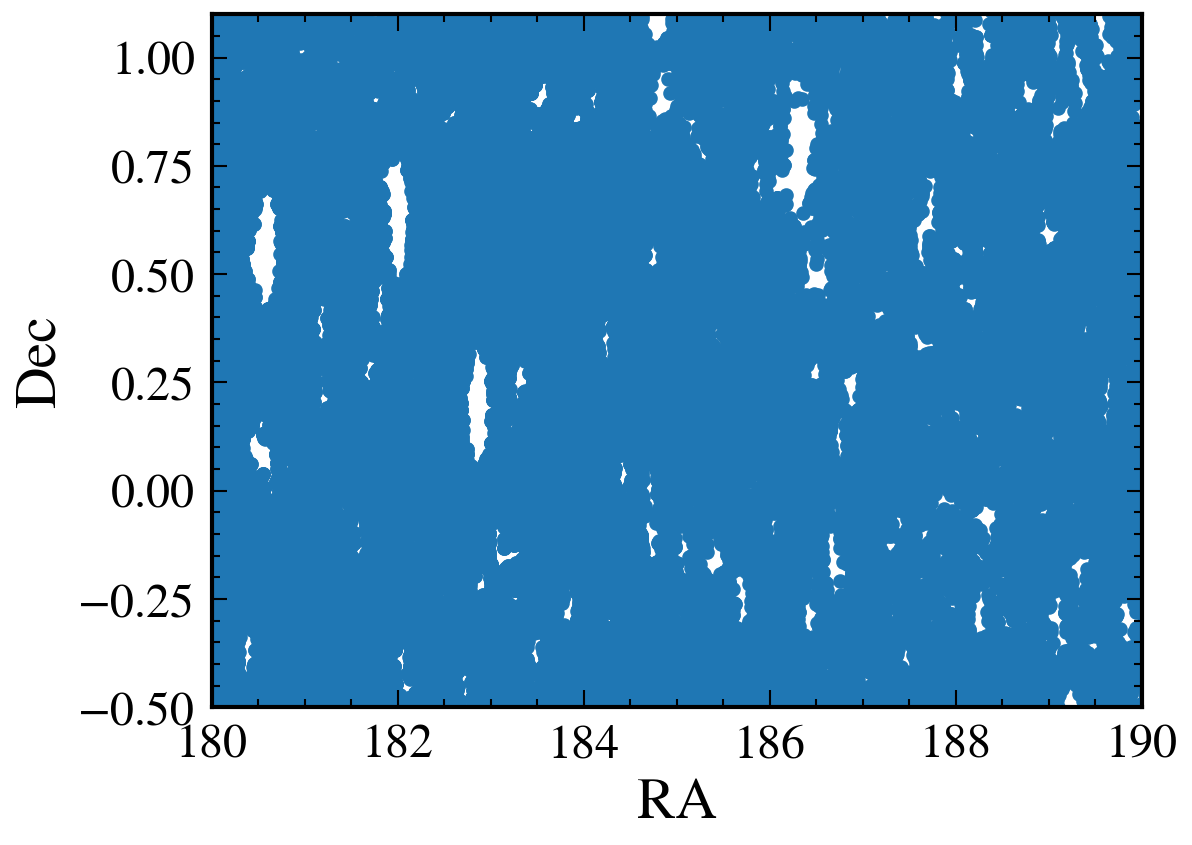

In [55]:
ra_hsc = hsc_catalog_matched['TARGET_RA']
dec_hsc = hsc_catalog_matched['TARGET_DEC']

# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra_hsc, dec_hsc)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(180, 190)
ax.set_ylim(-0.5, 1.1)
ax.grid(None)
# 130 < ra 200
# -2 < dec < 2
plt.show()

In [54]:
alpha_1 = 180
alpha_2 = 190
delta_1 = -0.5
delta_2 = 1.1

exact_area = calculate_sky_area(alpha_1, alpha_2, delta_1, delta_2)

print(f"RA Span: {alpha_2 - alpha_1}°")
print(f"Dec Min (rad): {math.radians(delta_1):.4f}")
print(f"Dec Max (rad): {math.radians(delta_2):.4f}")
print(f"Exact Area: {exact_area:.3f} square degrees")

RA Span: 10°
Dec Min (rad): -0.0087
Dec Max (rad): 0.0192
Exact Area: 15.999 square degrees


In [56]:
file_path = '/scratch/gpfs/js1998/matched_catalogs/hscy3_matched.csv'

query = (pl.scan_csv(file_path).filter(
        (pl.col('TARGET_RA') >= 180) & (pl.col('TARGET_RA') <= 190) &
        (pl.col('TARGET_DEC') >= -0.5) & (pl.col('TARGET_DEC') <= 1.1)))

hsc_full_catalog_ra_dec_cuts = query.collect()

print(f"Loaded {hsc_full_catalog_ra_dec_cuts.height} rows")

Loaded 235805 rows


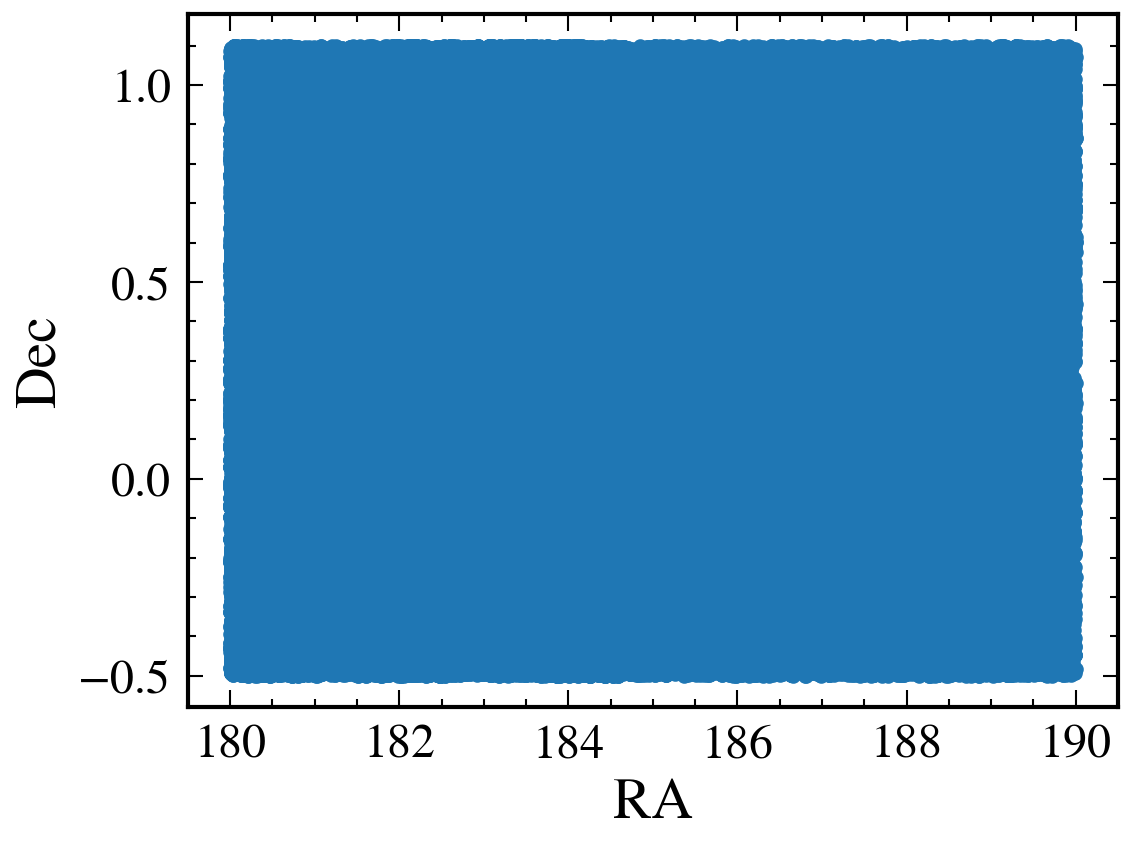

In [57]:
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(hsc_full_catalog_ra_dec_cuts['TARGET_RA'], hsc_full_catalog_ra_dec_cuts["TARGET_DEC"])
ax.set_xlabel("RA")
ax.set_ylabel("Dec")

ax.grid(None)
plt.show()

In [58]:
hsc_full_catalog_ra_dec_cuts

,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,SPECTYPE_BEST,SUBTYPE_BEST,CHI2_BEST,DELTACHI2_BEST,PETAL_LOC,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MIN_MJD,MAX_MJD,MEAN_MJD,GOOD_SPEC,EFFTIME_SPEC,ZCAT_NSPEC,ZCAT_PRIMARY,SV_NSPEC,SV_PRIMARY,MAIN_NSPEC,MAIN_PRIMARY,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,e_rms,lensing_weight,m_corr,lensing_match
i64,i64,str,str,i64,i64,f64,i64,f64,i64,str,str,f64,f64,i64,i64,i64,f64,f64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,bool,f64,i64,bool,i64,bool,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64
266500,2305843036766077308,"""b'main'""","""b'backup'""",41562,20220127,-0.000065,1,0.000003,0,"""b'STAR'""","""b'G'""",8036.2476,10322.245,3,1500,0,184.885334,-0.441219,"""b'DESI J184.8853-00.4412'""","""b'TGT'""",131.67871,66.62677,35,1,602.914,1,1,59607.461471,59607.461471,59607.461471,true,80.94451,1,true,0,false,1,true,0,2305843009213693952,0,576460795253096448,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
266501,2305843036766078823,"""b'main'""","""b'backup'""",41562,20220127,0.000005,1,9.6673e-7,0,"""b'STAR'""","""b'F'""",22171.795,165616.58,3,1501,0,184.854093,-0.420911,"""b'DESI J184.8540-00.4209'""","""b'TGT'""",139.4234,71.64213,30,1,602.914,1,1,59607.461471,59607.461471,59607.461471,true,79.17811,1,true,0,false,1,true,0,2305843009213693952,0,1152921504606846976,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
266503,-415623111,"""b'main'""","""b'backup'""",41562,20220127,1.455675,0,0.000321,2053,"""b'GALAXY'""",null,7314.5303,5.1455364,3,1503,1026,184.801725,-0.317292,"""b'DESI J184.8017-00.3172'""","""b'SKY'""",152.58057,97.19911,0,1,602.914,1,1,59607.461471,59607.461471,59607.461471,false,432.2209,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
266504,2305843036766082796,"""b'main'""","""b'backup'""",41562,20220127,-0.000119,1,0.000014,0,"""b'STAR'""","""b'F'""",7873.8213,2798.9326,3,1504,0,184.906724,-0.470856,"""b'DESI J184.9067-00.4708'""","""b'TGT'""",126.36847,59.34764,35,1,602.914,1,1,59607.461471,59607.461471,59607.461471,true,70.38255,1,true,0,false,1,true,0,2305843009213693952,0,576460795253096448,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
266505,2305843036766082643,"""b'main'""","""b'backup'""",41562,20220127,0.000031,1,0.000001,0,"""b'STAR'""","""b'G'""",13919.989,66899.06,3,1505,0,184.999755,-0.459145,"""b'DESI J184.9997-00.4591'""","""b'TGT'""",103.50384,62.13291,30,1,602.914,1,1,59607.461471,59607.461471,59607.461471,true,83.90638,1,true,0,false,1,true,0,2305843009213693952,0,1152921504606846976,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
120328440,39627775673369271,"""b'sv3'""","""b'dark'""",445,20210513,1.067908,3,0.000092,0,"""b'GALAXY'""",null,8255.817,86.86192,9,4940,0,180.282057,-0.419131,"""b'DESI J180.2820-00.4191'""","""b'TGT'""",-198.2317,-155.00575,2,2,2020.6672,1,1,59348.227098,59348.242885,59348.234992,true,1094.718,3,false,2,true,0,false,0,0,0,0,0,0,0,0,0,0,0,0,0,655394,0,0,0,180.282055,-0.419118,0.236602,0.040893,0.395915,6.35633,-0.061579,1
120328441,-4459207,"""b'sv3'""","""b'dark'""",445,20210513,0.471124,0,0.000067,2053,"""b'GALAXY'""",null,7626.571,2.543678,9,4941,1034,180.423147,-0.478229,"""b'DESI J180.4231-00.4782'""","""b'SKY'""",-234.35861,-170.53297,0,2,2020.6672,1,1,59348.227098,59348.242885,59348.234992,false,1740.4805,1,true,1,true,0,false,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

## DES

In [61]:
desy3 = '/scratch/gpfs/dy9683/matched_catalogs/desy3_matched_lensing_match_1.csv'
des_catalog_matched = pd.read_csv(desy3)

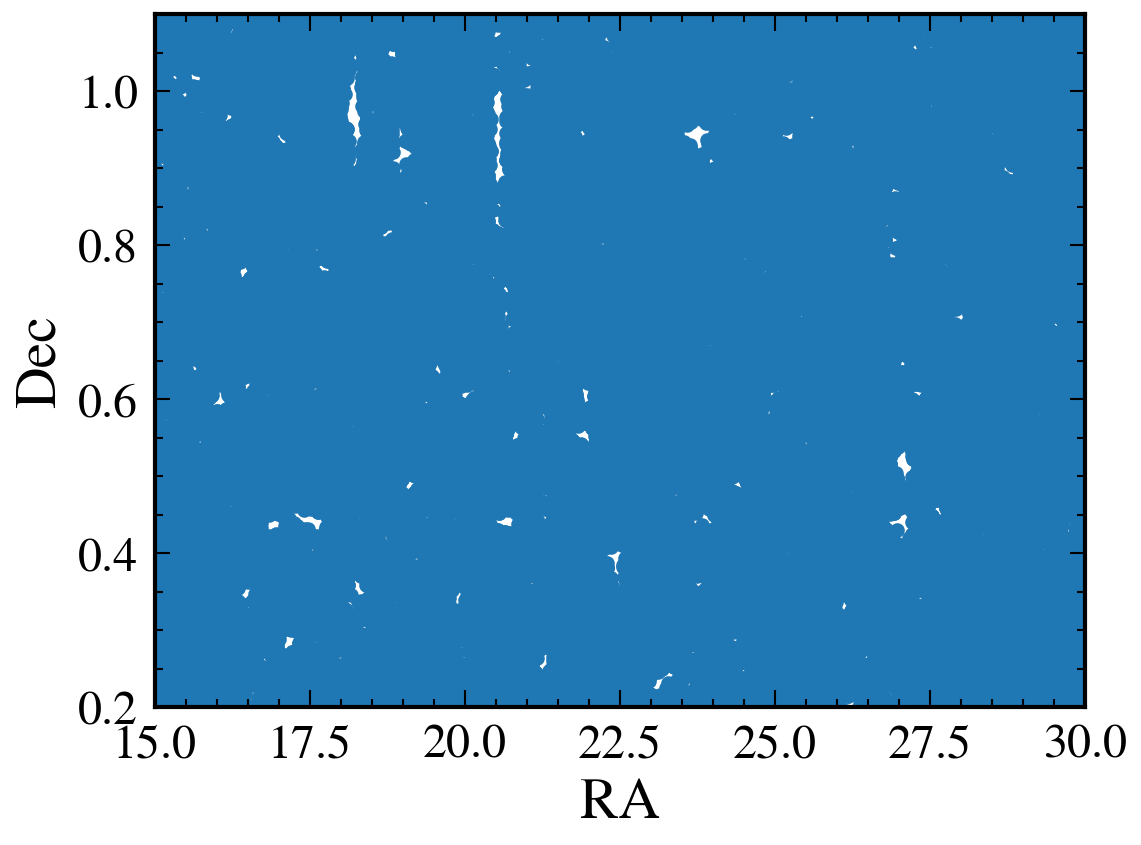

In [62]:
ra_des = des_catalog_matched['TARGET_RA']
dec_des = des_catalog_matched['TARGET_DEC']

# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra_des, dec_des)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(15, 30)
ax.set_ylim(0.2, 1.1)
ax.grid(None)
# 130 < ra 200
# -2 < dec < 2
plt.show()

In [63]:
alpha_1 = 15
alpha_2 = 30
delta_1 = 0.2
delta_2 = 1.1

exact_area = calculate_sky_area(alpha_1, alpha_2, delta_1, delta_2)

print(f"RA Span: {alpha_2 - alpha_1}°")
print(f"Dec Min (rad): {math.radians(delta_1):.4f}")
print(f"Dec Max (rad): {math.radians(delta_2):.4f}")
print(f"Exact Area: {exact_area:.3f} square degrees")

RA Span: 15°
Dec Min (rad): 0.0035
Dec Max (rad): 0.0192
Exact Area: 13.499 square degrees


In [64]:
file_path = '/scratch/gpfs/js1998/matched_catalogs/desy3_matched.csv'

query = (pl.scan_csv(file_path).filter(
        (pl.col('TARGET_RA') >= 15) & (pl.col('TARGET_RA') <= 30) &
        (pl.col('TARGET_DEC') >= 0.2) & (pl.col('TARGET_DEC') <= 1.1)))

des_full_catalog_ra_dec_cuts = query.collect()

print(f"Loaded {des_full_catalog_ra_dec_cuts.height} rows")

Loaded 111196 rows


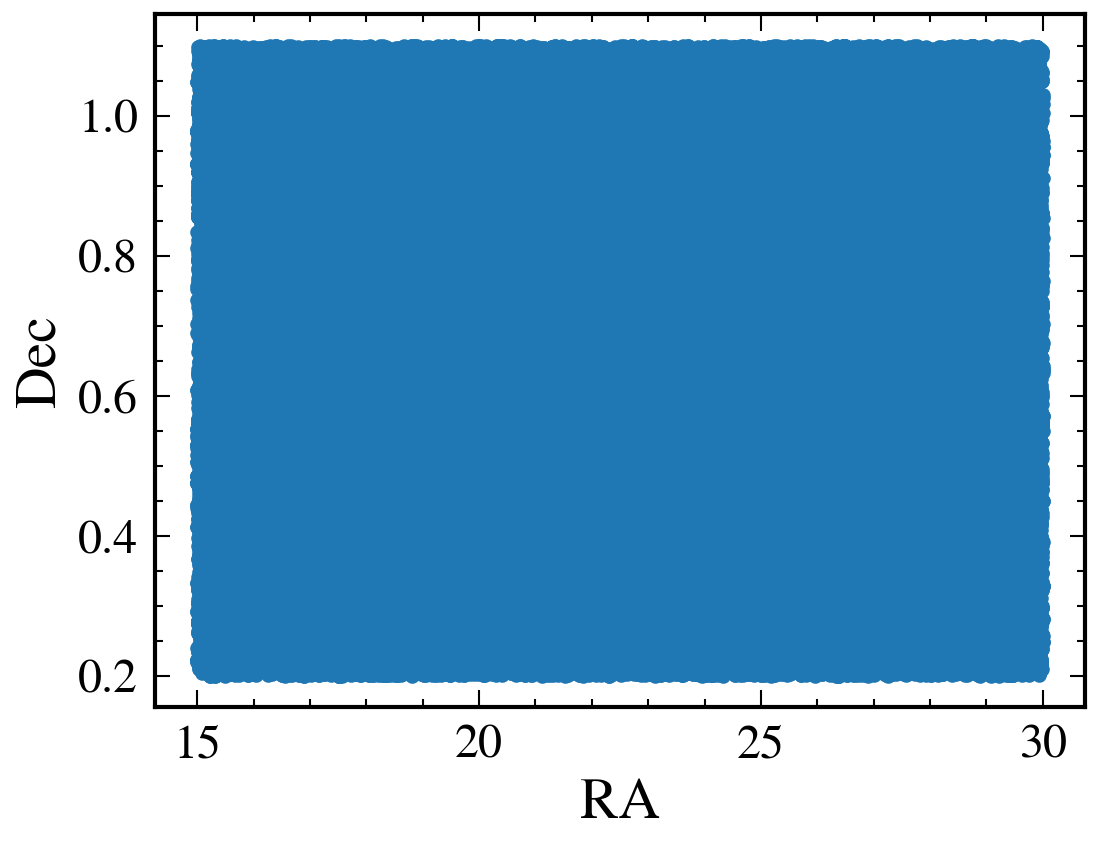

In [65]:
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(des_full_catalog_ra_dec_cuts['TARGET_RA'], des_full_catalog_ra_dec_cuts['TARGET_DEC'])
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(None)
plt.show()

In [66]:
des_full_catalog_ra_dec_cuts

,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,SPECTYPE_BEST,SUBTYPE_BEST,CHI2_BEST,DELTACHI2_BEST,PETAL_LOC,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MIN_MJD,MAX_MJD,MEAN_MJD,GOOD_SPEC,EFFTIME_SPEC,ZCAT_NSPEC,ZCAT_PRIMARY,SV_NSPEC,SV_PRIMARY,MAIN_NSPEC,MAIN_PRIMARY,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,lensing_weight,R11,R12,R21,R22,lensing_match
i64,i64,str,str,i64,i64,f64,i64,f64,i64,str,str,f64,f64,i64,i64,i64,f64,f64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,bool,f64,i64,bool,i64,bool,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
22000,-417124519,"""b'main'""","""b'backup'""",41712,20211206,1.417274,0,0.000086,2053,"""b'GALAXY'""",null,8082.956,7.2553105,4,2000,1026,26.614918,0.393595,"""b'DESI J026.6149+00.3935'""","""b'SKY'""",231.44527,332.7189,0,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,false,66.31335,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
22001,616088543516689276,"""b'main'""","""b'backup'""",41712,20211206,1.531258,0,0.000054,1,"""b'GALAXY'""",null,7705.638,35.74074,4,2001,0,26.621325,0.309569,"""b'DESI J026.6213+00.3095'""","""b'SKY'""",228.96368,310.22186,-1,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,false,65.797844,2,false,0,false,2,false,0,4294967296,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
22005,2305843027907706953,"""b'main'""","""b'backup'""",41712,20211206,-0.000143,1,0.000007,0,"""b'STAR'""","""b'K'""",9085.422,1160.0813,4,2005,0,26.707149,0.447954,"""b'DESI J026.7071+00.4479'""","""b'TGT'""",207.99371,346.395,35,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,true,66.3618,2,false,0,false,2,false,0,2305843009213693952,0,576460752303423488,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
22007,2305843027907710172,"""b'main'""","""b'backup'""",41712,20211206,-0.000096,1,0.000005,0,"""b'STAR'""","""b'G'""",8586.126,5204.232,4,2007,0,26.530324,0.241695,"""b'DESI J026.5303+00.2416'""","""b'TGT'""",252.01546,293.154,20,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,true,65.76754,1,true,0,false,1,true,0,2305843009213693952,0,2305843052163366912,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
22010,2305843027907709369,"""b'main'""","""b'backup'""",41712,20211206,0.000007,1,0.000004,0,"""b'STAR'""","""b'K'""",8889.355,7193.0796,4,2010,0,26.648734,0.333094,"""b'DESI J026.6487+00.3330'""","""b'TGT'""",222.06953,316.208,20,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,true,67.79952,2,false,0,false,2,false,0,2305843009213693952,0,2305843009213693952,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
107441447,39627809374601657,"""b'main'""","""b'dark'""",102079,20250929,1.375986,3,0.000151,0,"""b'GALAXY'""",null,8052.3896,104.87139,9,4947,0,29.00967,0.976605,"""b'DESI J029.0096+00.9766'""","""b'TGT'""",-159.1734,-336.99048,3000,1,857.6061,1,1,60948.351905,60948.351905,60948.351905,true,825.9468,1,true,0,false,1,true,0,1179778,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29.009634,0.976637,0.029464,-0.028927,26.945974,1.079825,-0.222162,0.078884,1.150712,1
107441448,39627809374605015,"""b'main'""","""b'dark'""",102079,20250929,0.930102,3,0.00002,0,"""b'GALAXY'""",null,7803.002,888.7532,9,4948,0,29.100359,0.960454,"""b'DESI J029.1003+00.9604'""","""b'TGT'""",-182.52905,-342.02887,2,1,857.6061,1,1,60948.351905,60948.351905,60948.351905,true,874.27

# Calculate Match Fraction

In [59]:
# calculate what fraction of hsc_full_catalog_ra_dec_cuts have 'lensing_match == 1"

In [69]:
hsc_lensing_match = (hsc_full_catalog_ra_dec_cuts['lensing_match'] == 1.0).sum()
print(f"Number of rows with lensing match = 1: {hsc_lensing_match}")

hsc_match_fraction = hsc_lensing_match / len(hsc_full_catalog_ra_dec_cuts)
print(f"The match fraction of HSC is:  {hsc_match_fraction}")

Number of rows with lensing match = 1: 53433
The match fraction of HSC is:  0.22659824855282967


In [71]:
des_lensing_match = (des_full_catalog_ra_dec_cuts['lensing_match'] == 1.0).sum()
print(f"Number of rows with lensing match = 1: {des_lensing_match}")

des_match_fraction = des_lensing_match / len(des_full_catalog_ra_dec_cuts)
print(f"The match fraction of DES is:  {des_match_fraction}")

Number of rows with lensing match = 1: 36793
The match fraction of DES is:  0.3308842044677866
